В данной работе проводится сравнения результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель билинейного изотропного упрочнения - **BISO**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [19]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress

real_experiment_data_folder = "."
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col="S_TT",
            s_y_col="S_ZZ",
            s_xy_col="S_TZ",
            new_col_name="S_EQV"
        )

### Методика проведения численного эксперимента

Расчет в **ANSYS** выполнялся в деформационном нагружении **поточечно**. Процесс моделирования был организован следующим образом:

*   **Синхронизация по шагам:** На каждом расчетном шаге (step) производилось прямое сопоставление с временной шкалой реального эксперимента.
*   **Граничные условия:** В качестве входных параметров численной модели на каждом шаге использовались компоненты тензора деформаций, полученные непосредственно из экспериментальных данных.
*   **Итерационный расчет:** Программа вычисляла отклик системы (напряжения) для каждой конкретной точки деформационного пути, что позволило обеспечить максимально точное соответствие условий нагружения в модели и в реальности.


In [20]:
from core.reader import read_ansys_csv

numerical_experiment_biso = read_ansys_csv("biso.csv")

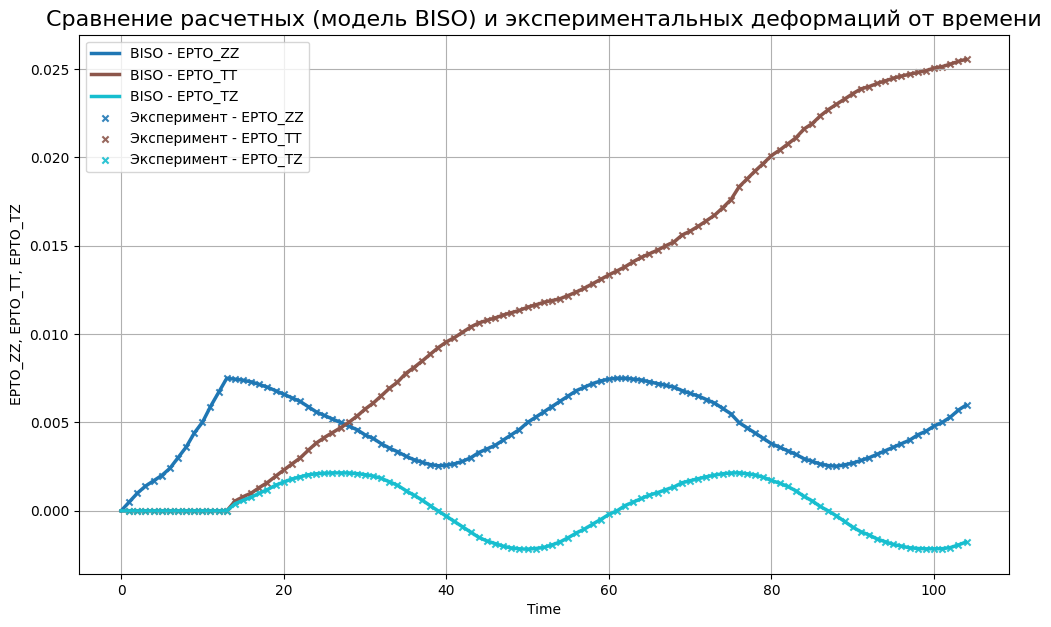

In [21]:
from core.visualizer import plot_xy

model_name = "BISO"
plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7)
)

Построим графики изменения компонент тензора напряжений и интенсивности напряжений от времени.

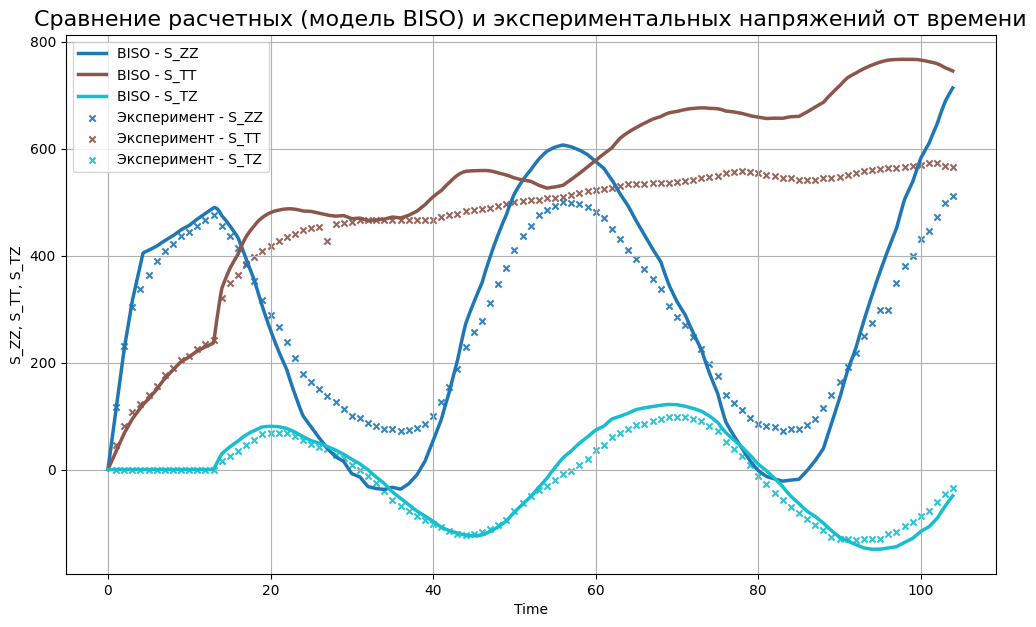

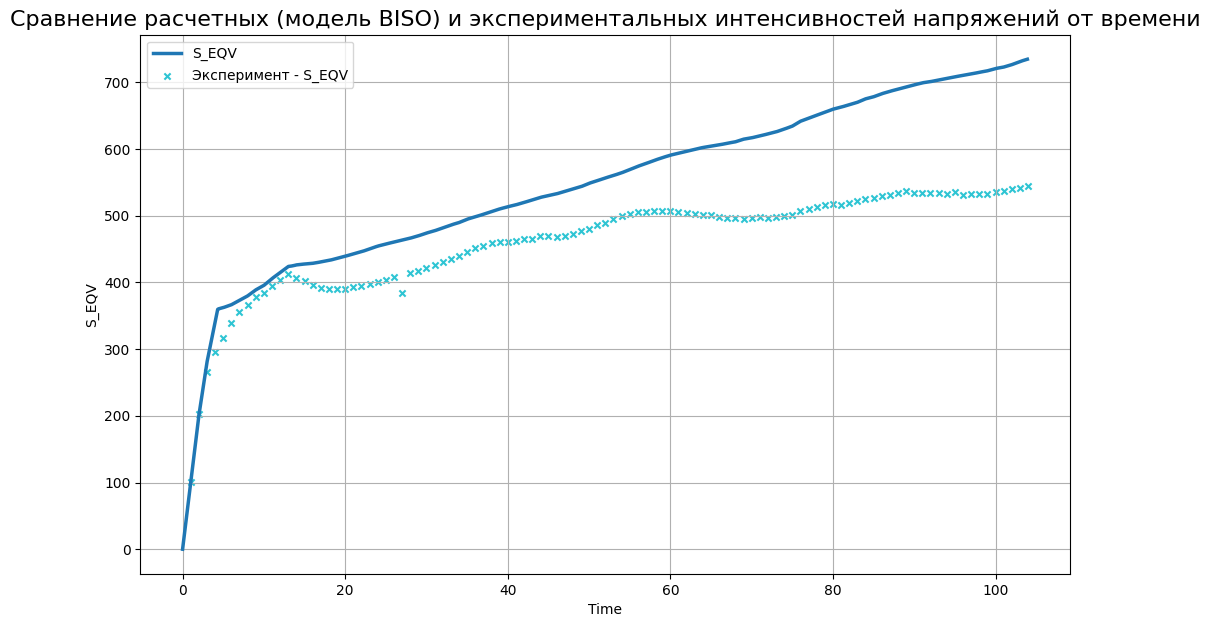

In [22]:
plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["S_ZZ", "S_TT", "S_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["S_EQV"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени",
    ("Эксперимент", real_experiment),
    figsize=(12, 7)
)

### Сравнительный анализ в пространстве Ильюшина и длина пути

В пространстве деформаций Ильюшина каждой точке процесса соответствует вектор $(\varepsilon_1^{Il}, \varepsilon_2^{Il}, \varepsilon_3^{Il})$, в пространстве напряжений Ильюшина — вектор $(\sigma_1^{Il}, \sigma_2^{Il}, \sigma_3^{Il})$.

**Длина дуги $s$.** Точки нагружения упорядочены по времени. Между двумя соседними точками задаём приращение
$\Delta\varepsilon_i^{Il} = \varepsilon_i^{Il}(t_{k+1}) - \varepsilon_i^{Il}(t_k)$, $i=1,2,3$.
Евклидова длина шага в пространстве деформаций Ильюшина:
$$\Delta s_k = \sqrt{(\Delta\varepsilon_1^{Il})^2 + (\Delta\varepsilon_2^{Il})^2 + (\Delta\varepsilon_3^{Il})^2}.$$
Накопленная длина пути от начала процесса: $s_0 = 0$, $s_k = \sum_{j=0}^{k-1} \Delta s_j$.

**Какие графики строятся.**
1. Компоненты $\varepsilon_1^{Il}, \varepsilon_2^{Il}, \varepsilon_3^{Il}$ от длины дуги $s$.
2. Компоненты $\sigma_1^{Il}, \sigma_2^{Il}, \sigma_3^{Il}$ от $s$.
3. Для сопоставления модели с экспериментом в **моменты измерений эксперимента** подбирается ближайший по времени шаг расчёта; в этих точках вычисляются угол между векторами напряжений Ильюшина и относительная разность модулей. **Графики** угла и относительной разности модулей строятся по оси абсцисс от **экспериментальной** длины дуги $s$.

#### Угол между векторами напряжений Ильюшина ($\varphi$)

Характеризует рассогласование **направлений** векторов напряжений расчёта $\vec{\sigma}^{\mathrm{числ}}$ и эксперимента $\vec{\sigma}^{\mathrm{эксп}}$:
$$\varphi = \arccos\left(\frac{\vec{\sigma}^{\mathrm{числ}} \cdot \vec{\sigma}^{\mathrm{эксп}}}{|\vec{\sigma}^{\mathrm{числ}}| \cdot |\vec{\sigma}^{\mathrm{эксп}}|}\right).$$
Значение $\varphi = 0$ соответствует совпадению направлений.

#### Относительная разность модулей

Характеризует рассогласование **величин** (норм векторов напряжений Ильюшина):
$$\frac{|\vec{\sigma}^{\mathrm{числ}}| - |\vec{\sigma}^{\mathrm{эксп}}|}{|\vec{\sigma}^{\mathrm{эксп}}|}.$$


In [23]:
from core.calculations import (
    ilushin_stress_metrics_at_experiment_times,
    prepare_ilushin_path_dataset,
)

exp_il = prepare_ilushin_path_dataset(real_experiment, compressible=False)
num_il = prepare_ilushin_path_dataset(numerical_experiment_biso, compressible=True)


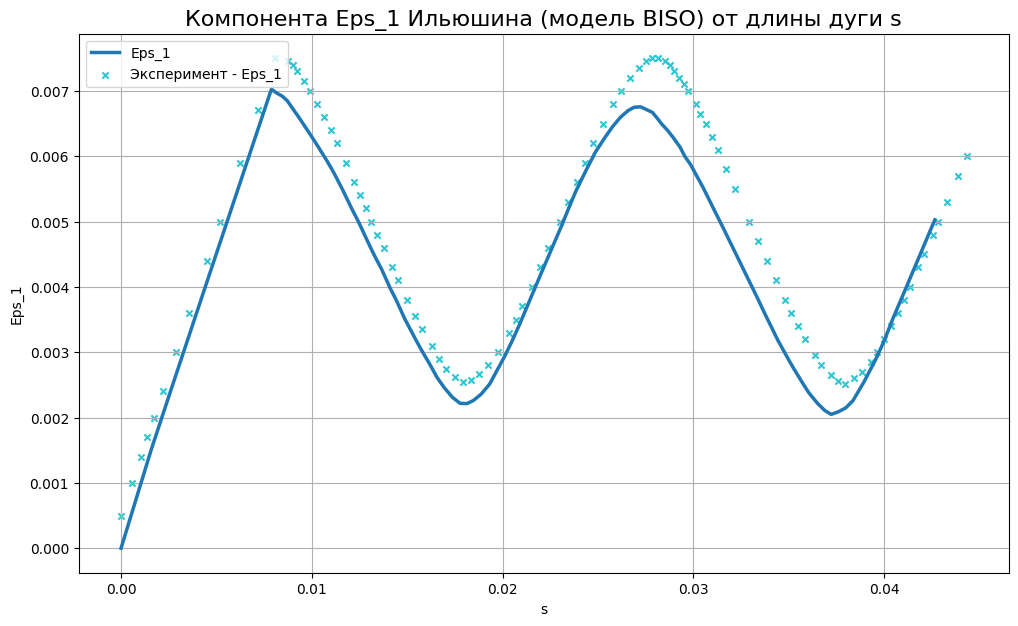

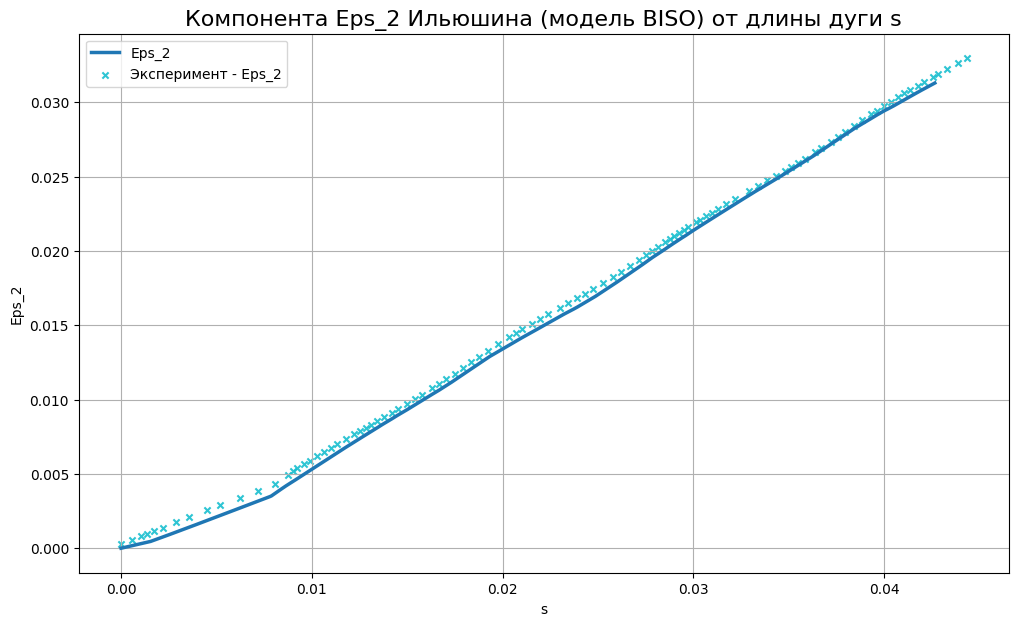

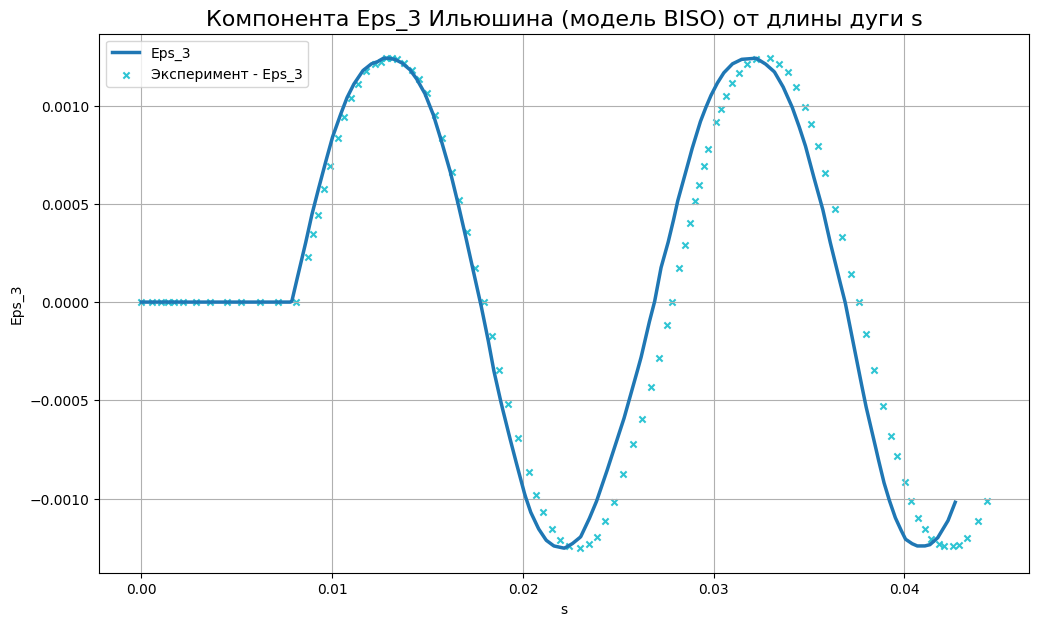

In [24]:
plot_xy(
    [(model_name, num_il)],
    "s",
    ["Eps_1"],
    f"Компонента Eps_1 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Eps_2"],
    f"Компонента Eps_2 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Eps_3"],
    f"Компонента Eps_3 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)


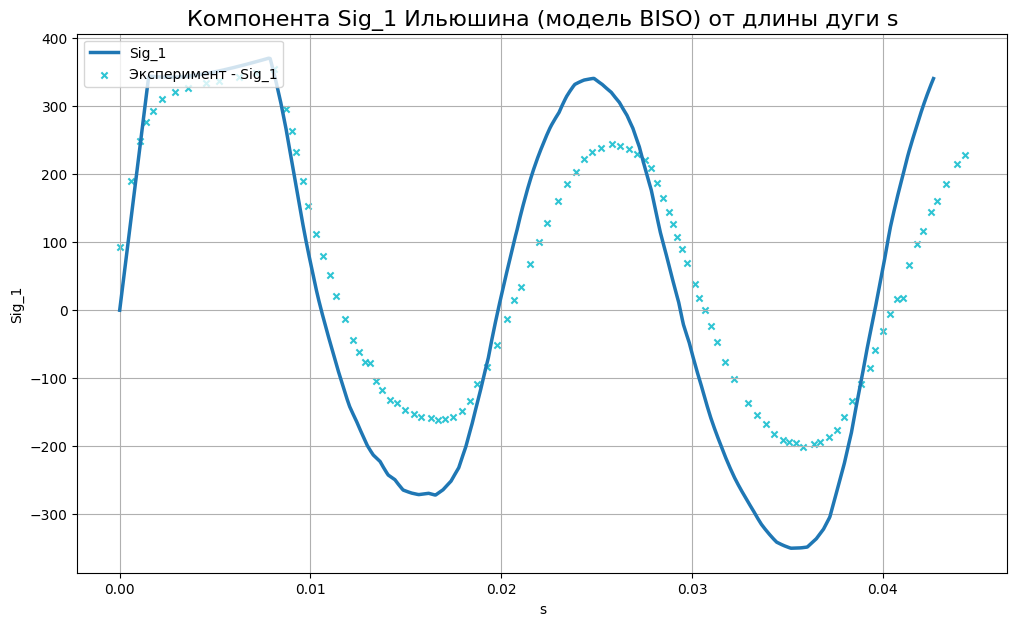

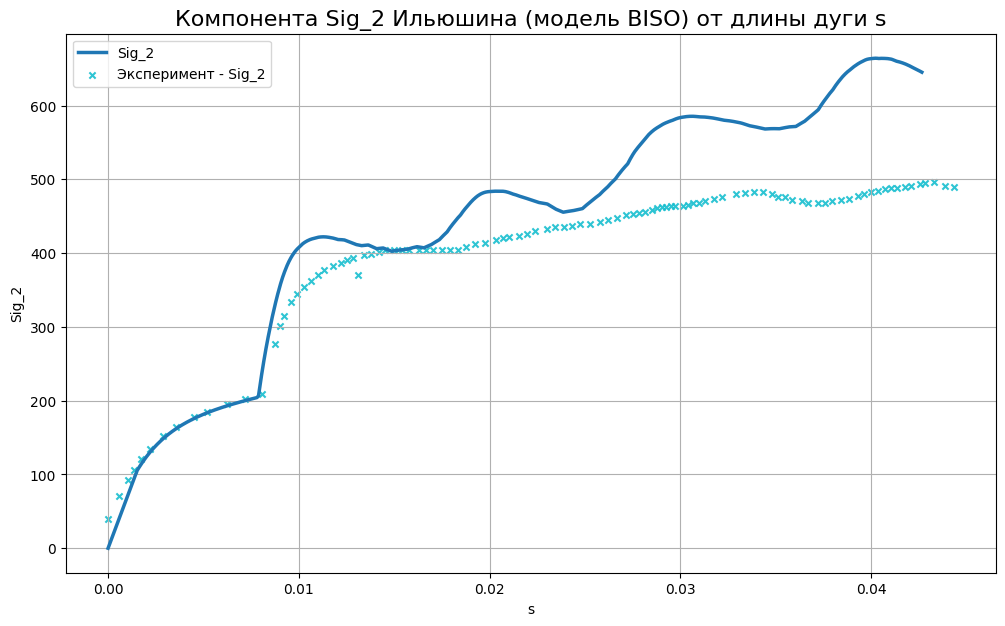

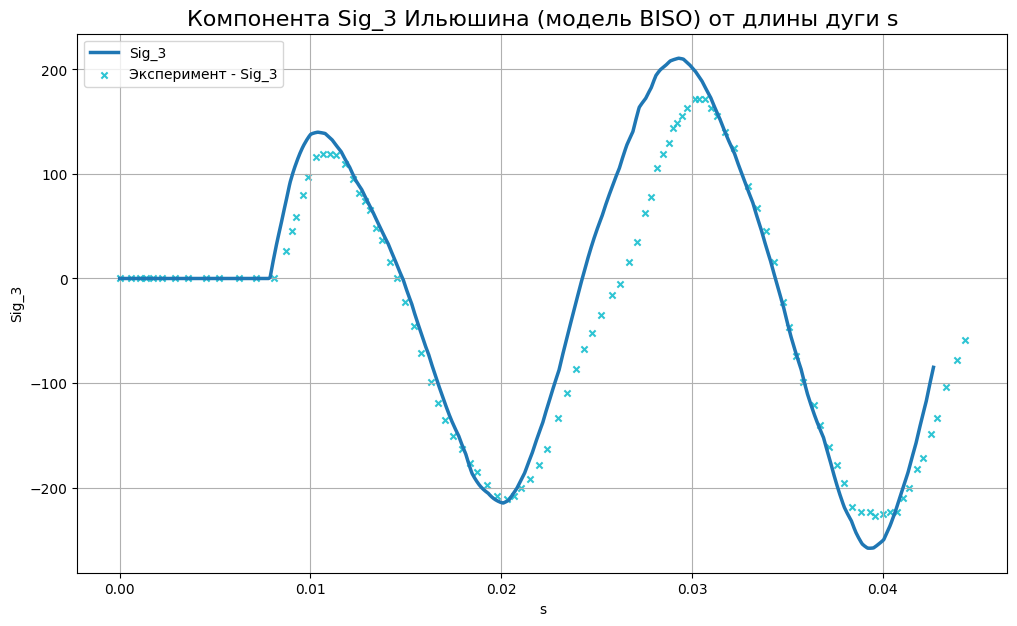

In [25]:
plot_xy(
    [(model_name, num_il)],
    "s",
    ["Sig_1"],
    f"Компонента Sig_1 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Sig_2"],
    f"Компонента Sig_2 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Sig_3"],
    f"Компонента Sig_3 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)


In [26]:
df_metrics = ilushin_stress_metrics_at_experiment_times(
    real_experiment,
    numerical_experiment_biso,
    time_col="Time",
    compressible=False,
    direction="nearest",
)


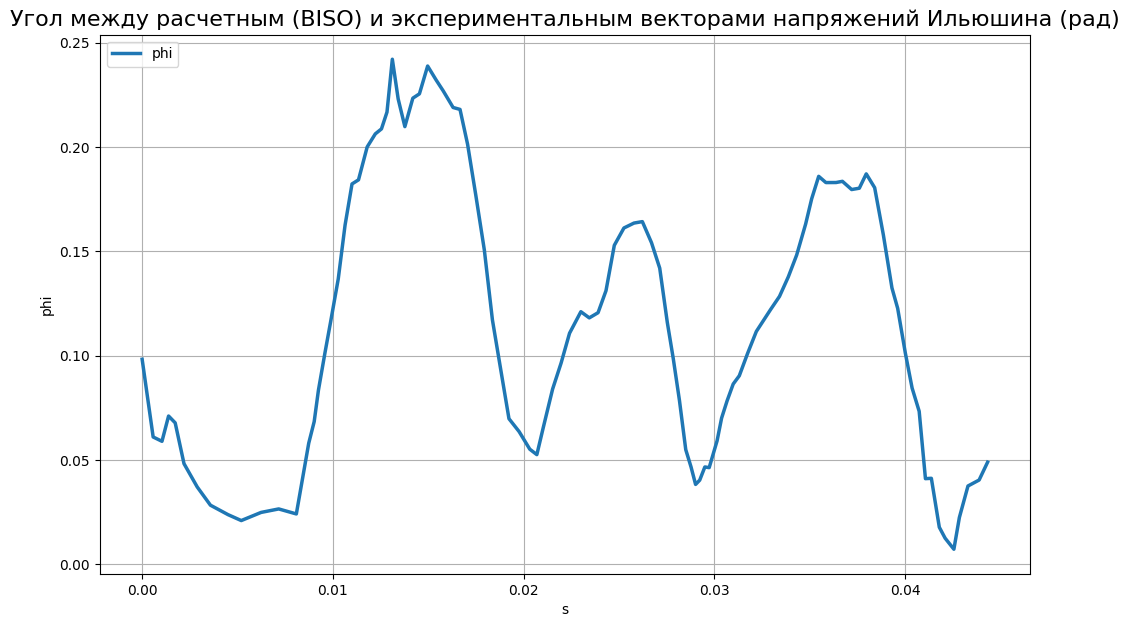

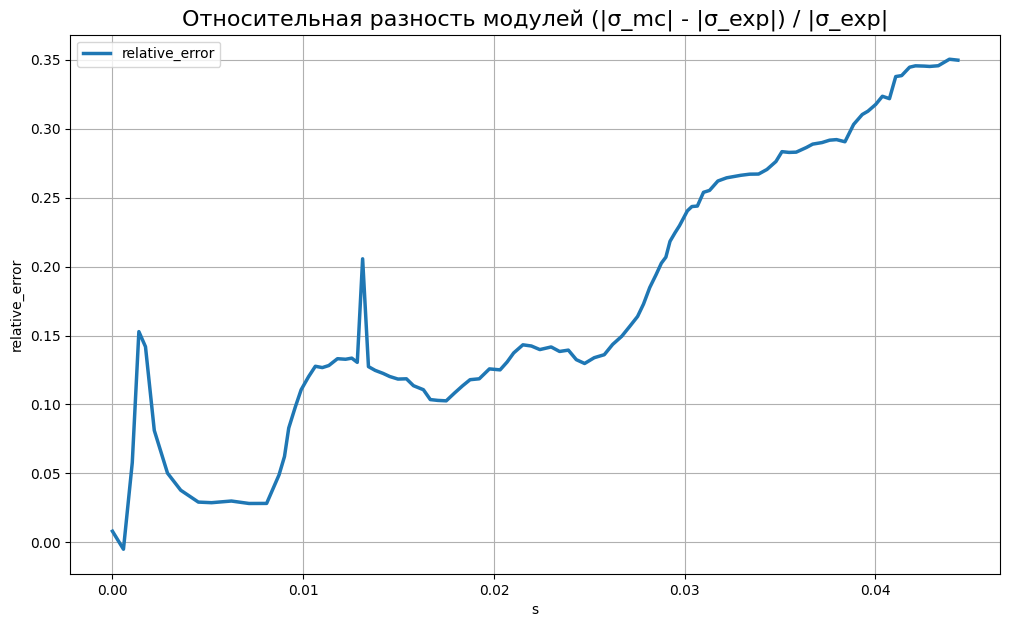

In [27]:
plot_xy(
    data_pairs=[(model_name, df_metrics)],
    x_col="s",
    y_cols=["phi"],
    title=f"Угол между расчетным ({model_name}) и экспериментальным векторами напряжений Ильюшина (рад)",
    figsize=(12, 7),
)

plot_xy(
    data_pairs=[(model_name, df_metrics)],
    x_col="s",
    y_cols=["relative_error"],
    title=f"Относительная разность модулей (|σ_mc| - |σ_exp|) / |σ_exp|",
    figsize=(12, 7),
)


### Интенсивность $|\Sigma|$ и угол сближения $\Theta$ vs глобальная дуга $s$ (весь путь)

Модуль вектора напряжений Ильюшина $|\Sigma| = \sqrt{\sigma_1^2+\sigma_2^2+\sigma_3^2}$ и угол сближения между $\boldsymbol{\sigma}^{\mathrm{Il}}$ и $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$. Производные по дуге считаются **`np.gradient`** по **фактическим** компонентам $\varepsilon^{\mathrm{Il}}$ отдельно для опыта и для ANSYS (как единая постановка сравнения). **Без** аппроксимации $\sigma_{\mathrm{mean}}(s)$+винт и **без** дополнительной третьей кривой на графике $\Theta$.


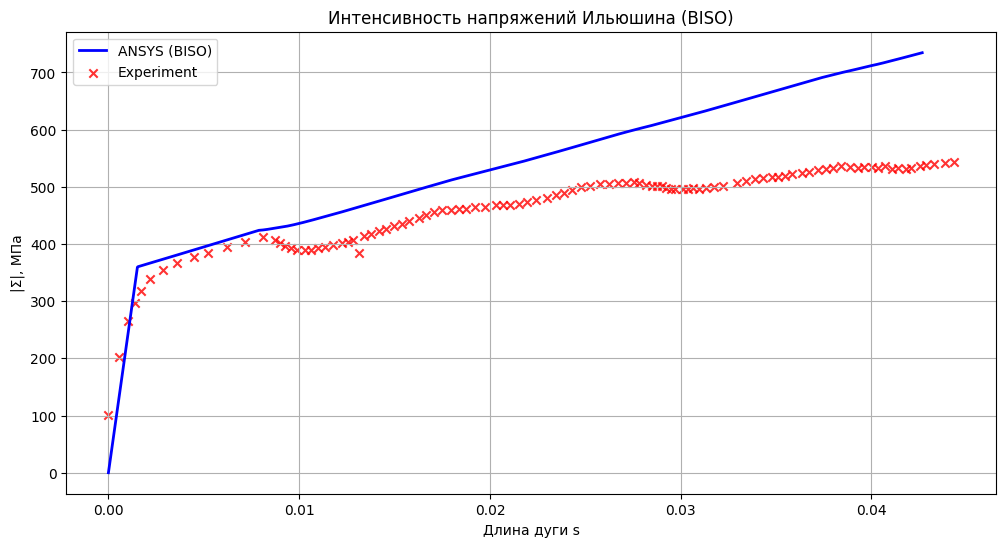

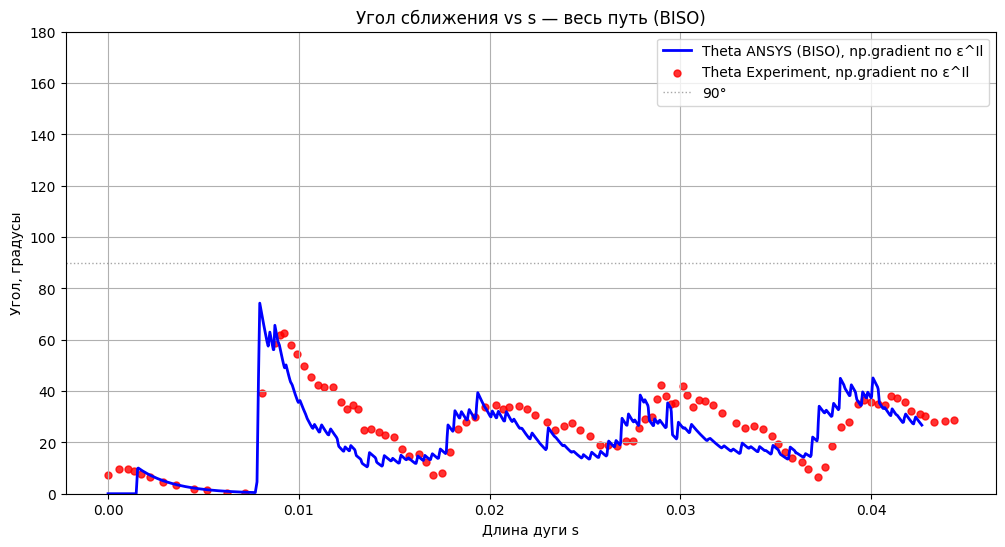

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.calculations import (
    ilushin_strain_arc_length_by_time,
    calculate_stress_vector,
    calculate_theta,
    calculate_ilushin_strain_vector,
)

re = real_experiment.copy()
re["S_TZ"] = -re["S_TZ"]
re["EPTO_TZ"] = -re["EPTO_TZ"]

sg_e = ilushin_strain_arc_length_by_time(re, time_col="Time", compressible=False)
re = re.merge(sg_e[["Time", "s"]], on="Time", how="inner")
re.rename(columns={"s": "s_il"}, inplace=True)

nc = numerical_experiment_biso.copy()
sg_n = ilushin_strain_arc_length_by_time(nc, time_col="Time", compressible=True)
nc = nc.merge(sg_n[["Time", "s"]], on="Time", how="inner")
nc.rename(columns={"s": "s_il"}, inplace=True)

s1, s2, s3 = calculate_stress_vector(re)
re["Sig_1"], re["Sig_2"], re["Sig_3"] = s1.values, s2.values, s3.values
n1, n2, n3 = calculate_stress_vector(nc)
nc["Sig_1"], nc["Sig_2"], nc["Sig_3"] = n1.values, n2.values, n3.values

il_re = calculate_ilushin_strain_vector(re, compressible=False)
re = re.merge(il_re[["Time", "Eps_1", "Eps_2", "Eps_3"]], on="Time", how="inner")
re_s = re.sort_values("s_il", kind="mergesort").reset_index(drop=True)
E_re = re_s[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
s_re = re_s["s_il"].to_numpy(dtype=float)
d_re = np.gradient(E_re, s_re, axis=0, edge_order=2)
df_te = pd.DataFrame(
    {
        "Sig_1": re_s["Sig_1"].values,
        "Sig_2": re_s["Sig_2"].values,
        "Sig_3": re_s["Sig_3"].values,
        "dEps_1_grad": d_re[:, 0],
        "dEps_2_grad": d_re[:, 1],
        "dEps_3_grad": d_re[:, 2],
    }
)
re_s["Theta"] = calculate_theta(df_te, deriv_suffix="_grad")
re = re.drop(columns=["Theta"], errors="ignore").merge(re_s[["Time", "Theta"]], on="Time", how="left")

nc_s = nc.sort_values("s_il", kind="mergesort").reset_index(drop=True)
il_nc = calculate_ilushin_strain_vector(nc_s, compressible=True)
nc_s = nc_s.merge(il_nc[["Time", "Eps_1", "Eps_2", "Eps_3"]], on="Time", how="inner")
nc_s = nc_s.sort_values("s_il", kind="mergesort").reset_index(drop=True)
s_num = nc_s["s_il"].to_numpy(dtype=float)
E_num = nc_s[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
d_num = np.gradient(E_num, s_num, axis=0, edge_order=2)
df_tn = pd.DataFrame(
    {
        "Sig_1": nc_s["Sig_1"].values,
        "Sig_2": nc_s["Sig_2"].values,
        "Sig_3": nc_s["Sig_3"].values,
        "dEps_1_grad": d_num[:, 0],
        "dEps_2_grad": d_num[:, 1],
        "dEps_3_grad": d_num[:, 2],
    }
)
nc_s["Theta"] = calculate_theta(df_tn, deriv_suffix="_grad")

re["S_EQV_il"] = np.sqrt(re["Sig_1"] ** 2 + re["Sig_2"] ** 2 + re["Sig_3"] ** 2)
nc_s["S_EQV_il"] = np.sqrt(nc_s["Sig_1"] ** 2 + nc_s["Sig_2"] ** 2 + nc_s["Sig_3"] ** 2)

plt.figure(figsize=(12, 6))
plt.plot(nc_s["s_il"], nc_s["S_EQV_il"], "b-", lw=2, label=f"ANSYS ({model_name})")
plt.scatter(re["s_il"], re["S_EQV_il"], c="r", marker="x", alpha=0.8, label="Experiment")
plt.title(f"Интенсивность напряжений Ильюшина ({model_name})")
plt.xlabel("Длина дуги s")
plt.ylabel("|Σ|, МПа")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(
    nc_s["s_il"],
    nc_s["Theta"],
    "b-",
    lw=2,
    label=f"Theta ANSYS ({model_name}), np.gradient по ε^Il",
)
plt.scatter(
    re["s_il"],
    re["Theta"],
    c="r",
    marker="o",
    s=25,
    alpha=0.8,
    label="Theta Experiment, np.gradient по ε^Il",
)
plt.title(f"Угол сближения vs s — весь путь ({model_name})")
plt.xlabel("Длина дуги s")
plt.ylabel("Угол, градусы")
plt.axhline(90, color="gray", ls=":", lw=1, alpha=0.7, label="90°")
plt.legend()
plt.grid(True)
plt.ylim(0, 180)
plt.show()




#### Выводы

**Деформации в пространстве Ильюшина ($\varepsilon_i^{Il}$ от длины дуги $s$), численный расчёт — сжимаемый материал.**  
Компонента $\varepsilon_2^{Il}$ на основной части пути ($s \gtrsim 0{,}01$) совпадает с экспериментом очень близко: общий почти линейный рост с $s$, у расчёта виден излом наклона около $s \approx 0{,}008$ (переход к развитию пластических деформаций), далее кривые практически накладываются. В самом начале пути расчёт слегка занижает деформацию относительно опыта.  
Для $\varepsilon_1^{Il}$ колебательный характер согласован по фазе, но **амплитуда у расчёта меньше**: модель **недооценивает** величину компоненты по сравнению с экспериментом, к концу пути расхождение усиливается.  
Для $\varepsilon_3^{Il}$ после начального нулевого участка **амплитуды** колебаний у расчёта и опыта близки, однако с ростом $s$ нарастает **фазовый сдвиг**: экстремумы экспериментальных точек смещены к **большим** $s$ по сравнению с расчётной кривой (расчёт «опережает» по накопленной дуге).

**Напряжения в пространстве Ильюшина ($\sigma_i^{Il}$ от $s$).**  
По всем трём компонентам модель BISO даёт **завышенную по модулю** реакцию по сравнению с экспериментом: пики расчёта выше, впадины для $\sigma_1^{Il}$ глубже — визуально материал в модели «жёстче» или сильнее упрочняется, чем в опыте. Для $\sigma_2^{Il}$ расчётная кривая сильно **осциллирует**, тогда как эксперимент идёт гладче и почти линейно на длинном участке; в конце пути расчёт выходит значительно выше опыта (порядка нескольких десятков процентов по величине на графике). Для $\sigma_3^{Il}$ после начального участка с нулевой компонентой обе серии колеблются с близкой частотой, но модель снова даёт **большую амплитуду** и **запаздывание по $s$** относительно эксперимента. В совокупности это указывает на ограниченность билинейной изотропной модели упрочнения для данной винтовой траектории: закон, заложенный в BISO, не полностью совпадает с фактической кинетикой напряжений в выбранных координатах Ильюшина.

**Угол $\varphi$ между векторами напряжений Ильюшина.**  
Направление вектора напряжений в расчёте и в эксперименте **не совпадает равномерно** по пути: угол изменяется от долей до ~0,24 рад (порядка 14°) в наиболее неблагоприятной точке; есть участки с малым $\varphi$ (близкое совпадение направлений) и выраженные пики на отдельных этапах нагружения. Такая неоднородность типична для сложного непропорционального пути: изотропное упрочнение не гарантирует совпадение направления реакции в плоскости Ильюшина на всём интервале.

**Относительная разность модулей $(|\vec{\sigma}^{\mathrm{числ}}| - |\vec{\sigma}^{\mathrm{эксп}}|) / |\vec{\sigma}^{\mathrm{эксп}}|$.**  
В начале пути виден **переходный выброс** (до порядка 15 %), затем интервал с относительно низкой ошибкой (несколько процентов), далее — участки с ростом примерно до 10–20 % и **систематическое увеличение к концу траектории** до около 35 %. Это согласуется с завышением модулей напряжений на графиках $\sigma_i^{Il}$: по мере накопления пластической деформации расчёт отходит от эксперимента по **величине** вектора напряжений Ильюшина сильнее, чем в начале процесса.

**Итог.**  
По деформациям Ильюшина лучше всего согласована $\varepsilon_2^{Il}$; по $\varepsilon_1^{Il}$ расчёт занижает амплитуду колебаний, по $\varepsilon_3^{Il}$ амплитуды близки, но растёт фазовый сдвиг относительно опыта. По напряжениям Ильюшина и по скалярным метрикам ($\varphi$ и относительная разность модулей) расчёт BISO **завышает жёсткость/уровень напряжений** и даёт **рассогласование направления** на отдельных этапах; к **концу** рассматриваемого пути **ошибка по модулю** становится наиболее существенной. Для улучшения согласования целесообразна настройка параметров упрочнения и/или переход к более гибкой модели с учётом эволюции поверхности текучести и накопления деформаций на непропорциональных траекториях.
